# Analisis de datos de las ocupaciones de AO5

Usamos los datos de la campaña A05 para hacer distintas representaciones teniendo en cuenta distintos aspectos del mismo

In [72]:
# Importamos los paquetes necesarios
import numpy as np
import matplotlib.pyplot as plt
import cartopy 
import xarray as xr
import glob
import os
from scipy.interpolate import LinearNDInterpolator

Abrimos el archivo que nos interesa analizar y vemos la información de los metadatos

In [73]:
ruta = "./Data/direct_downloads/A05/29AH20110128_ctd.nc"
ds = xr.open_dataset(ruta)

ds

<xarray.Dataset> Size: 28MB
Dimensions:             (N_PROF: 167, N_LEVELS: 3023)
Coordinates:
    expocode            (N_PROF) object 1kB ...
    station             (N_PROF) object 1kB ...
    cast                (N_PROF) int32 668B ...
    time                (N_PROF) datetime64[ns] 1kB ...
    latitude            (N_PROF) float64 1kB ...
    longitude           (N_PROF) float64 1kB ...
    sample              (N_PROF, N_LEVELS) object 4MB ...
    pressure            (N_PROF, N_LEVELS) float64 4MB ...
Dimensions without coordinates: N_PROF, N_LEVELS
Data variables:
    section_id          (N_PROF) object 1kB ...
    btm_depth           (N_PROF) float64 1kB ...
    pressure_qc         (N_PROF, N_LEVELS) float32 2MB ...
    ctd_temperature     (N_PROF, N_LEVELS) float64 4MB ...
    ctd_temperature_qc  (N_PROF, N_LEVELS) float32 2MB ...
    ctd_salinity        (N_PROF, N_LEVELS) float64 4MB ...
    ctd_salinity_qc     (N_PROF, N_LEVELS) float32 2MB ...
    ctd_oxygen_ml_l     (N_PROF, N_LEVELS) float64 4MB ...
    ctd_oxygen_ml_l_qc  (N_PROF, N_LEVELS) float32 2MB ...
    profile_type        (N_PROF) object 1kB ...
    geometry_container  float64 8B ...
Attributes:
    Conventions:               CF-1.8 CCHDO-1.0
    cchdo_software_version:    hydro 1.0.2.3
    cchdo_parameters_version:  params 0.1.21
    comments:                  CTD,20150223SIOODFADQ
    featureType:               profile

## Representación: Temperatura-longitud-presión 
Observamos la ficha de metadatos. Vamos a empezar representando presión frente temperatura y longitud con contour. Para ello, tenemos que tener todos los archivos con la misma dimensión. La temperatura cuando la copiamos en un array tiene dimensión (167, 3023), la presión igual. Sin embargo longitud no, por lo que habrá que añadirle una dimensión extra. Para ello creamos un array de dimensión (1, 3023) y multiplicamos ambos arrays, luego usamos contour. También hay un problema añadido, y es que presión y es que las variables tienen valores Nan que no pueden ser representados. Para eliminarlos, tenemos los datos de control de cálidad asociados. De está forma podemos quedarnos solo con los datos que cumplar un criterio de calidad. La calidad tiene valores de 0 a 9, siendo 0 la mejor y 9 la peor. Como criterio inicial vamos a restringir el dataset a los datos cuya calidad en cada una de las variables sea de 3 o inferior

### Interpolación con pcolormesh

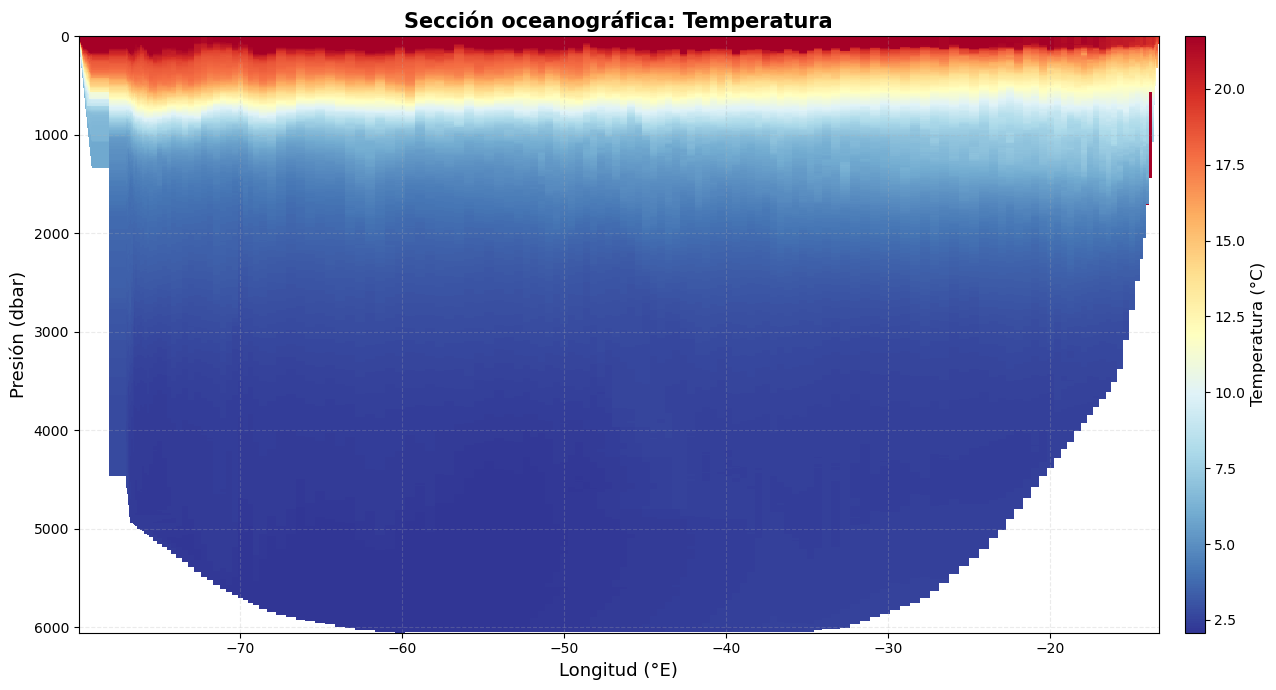

In [74]:
lon = ds.longitude.to_numpy()
pressure = ds.pressure.to_numpy()
temp = ds.ctd_temperature.to_numpy()



# mask = ctd_temperature_qc >= 3
# ── Preparar puntos conocidos (eliminando NaN) ───────────────
lon_2d = np.tile(lon[:, None], (1, pressure.shape[1]))   # (167, 3032)

mask   = ~np.isnan(pressure) & ~np.isnan(temp)

points = np.column_stack([lon_2d[mask], pressure[mask]]) # (N_valid, 2)
values = temp[mask]                                       # (N_valid,)

# ── Grid regular de consulta ─────────────────────────────────
p_common         = np.linspace(np.nanmin(pressure), np.nanmax(pressure), 500)
LON, PRES        = np.meshgrid(lon, p_common, indexing="ij")  # (167, 500)

# ── Interpolación 2D sin bucles ──────────────────────────────
interp    = LinearNDInterpolator(points, values)
temp_grid = interp(LON, PRES)                            # (167, 500)

# ── pcolormesh ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

pcm = ax.pcolormesh(
    LON, PRES, temp_grid,
    cmap="RdYlBu_r",
    shading="auto",
    vmin=np.nanpercentile(temp_grid, 2),
    vmax=np.nanpercentile(temp_grid, 98),
)

cbar = fig.colorbar(pcm, ax=ax, pad=0.02, aspect=30)
cbar.set_label("Temperatura (°C)", fontsize=12)

ax.set_xlabel("Longitud (°E)", fontsize=13)
ax.set_ylabel("Presión (dbar)", fontsize=13)
ax.set_title("Sección oceanográfica: Temperatura", fontsize=15, fontweight="bold")
ax.invert_yaxis()
ax.grid(alpha=0.25, linestyle="--")

plt.tight_layout()
plt.show()


### Scatter

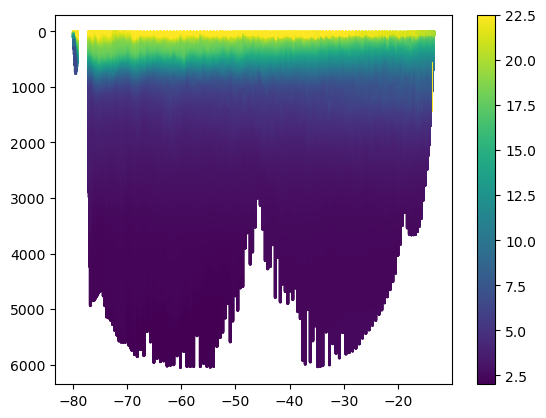

In [75]:
lon = ds.longitude.to_numpy()
press = ds.pressure.to_numpy()
temp = ds.ctd_temperature.to_numpy()

lon_2d = np.tile(lon[:, None], (1, press.shape[1])) # Mismas dimensiones que temp y press

fig, ax = plt.subplots()
pcm = ax.scatter(lon_2d, press, c = temp ,vmax = 22.5, s = 1)
fig.colorbar(pcm, ax = ax)
ax.invert_yaxis()
plt.show()

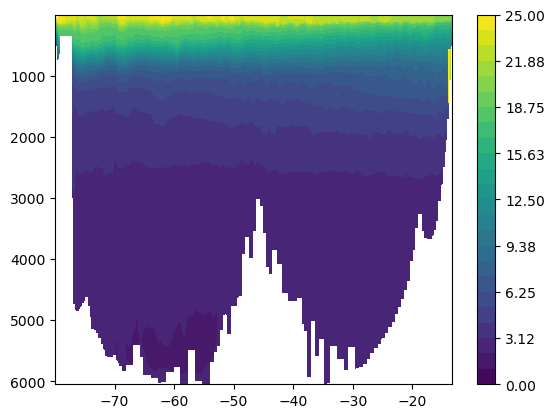

In [111]:
lon = ds.longitude.to_numpy()
press = ds.pressure.to_numpy()
temp = ds.ctd_temperature.to_numpy()

mask   = ~np.isnan(press) & ~np.isnan(temp)
P = press[mask]
lon_2d = np.tile(lon[:, None], (1, 3023))

# Creamos linspace de presión del máximo al mínimo
p = np.linspace(P.min(), P.max(), press.shape[1]) # (3023,)
PRES = np.tile(p[:,None], (1, press.shape[0]))
PRESS = PRES.T


fig, ax = plt.subplots()
pcm = ax.contourf(lon_2d, PRESS, temp,levels = np.linspace(0, 25, 25))
fig.colorbar(pcm, ax = ax)
ax.invert_yaxis()
plt.show()

### Salinidad-Longitud-Presión

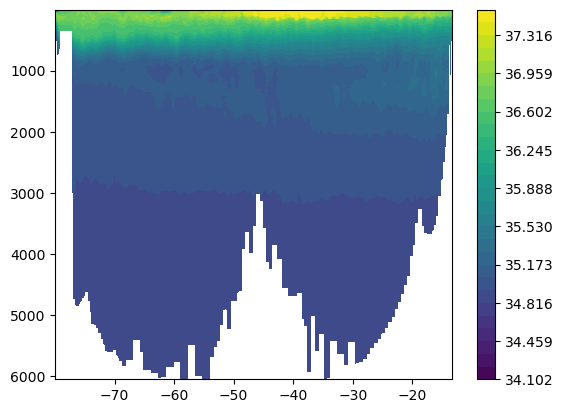

In [32]:
lon = ds.longitude.to_numpy()
press = ds.pressure.to_numpy()
sal = ds.ctd_salinity.to_numpy()

mask   = ~np.isnan(press) & ~np.isnan(sal)
P = press[mask]
lon_2d = np.tile(lon[:, None], (1, 3023))

SAL = sal[mask]

# Creamos linspace de presión del máximo al mínimo
p = np.linspace(P.min(), P.max(), press.shape[1]) # (3023,)
PRES = np.tile(p[:,None], (1, press.shape[0]))
PRESS = PRES.T


fig, ax = plt.subplots()
pcm = ax.contourf(lon_2d, PRESS, sal, levels = np.linspace(np.percentile(SAL, 0.12), SAL.max(), 30))
fig.colorbar(pcm, ax = ax)
ax.invert_yaxis()
plt.show()

### Oxigeno-Longitud-Presión

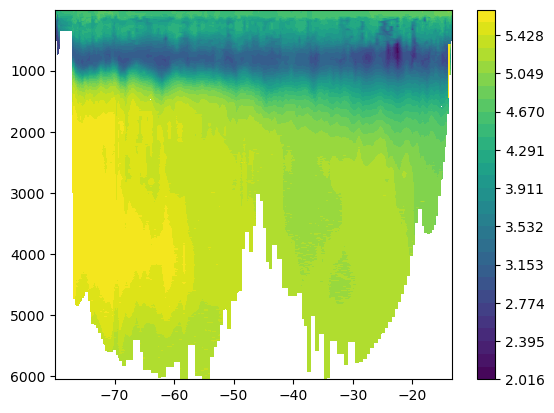

In [46]:
lon = ds.longitude.to_numpy()
press = ds.pressure.to_numpy()
oxi = ds.ctd_oxygen_ml_l.to_numpy()

mask   = ~np.isnan(press) & ~np.isnan(oxi)
P = press[mask]
lon_2d = np.tile(lon[:, None], (1, 3023))

OXI = oxi[mask]

# Creamos linspace de presión del máximo al mínimo
p = np.linspace(P.min(), P.max(), press.shape[1]) # (3023,)
PRES = np.tile(p[:,None], (1, press.shape[0]))
PRESS = PRES.T


fig, ax = plt.subplots()
pcm = ax.contourf(lon_2d, PRESS, oxi, levels = np.linspace(OXI.min(), np.percentile(OXI,99.8), 30))
fig.colorbar(pcm, ax = ax)
ax.invert_yaxis()
plt.show()

## Función para representaciones más generales

Dado que ya sabemos hacer una representación de una variable con la presión y la longitud. Vamos a plantearnos algo más genérico. La idea es generar una función que devuelva los arrays de las 3 variables, una como coordenada x, otra como coordenada y, y otra a color. Para ello el procedimiento será similar al planteado anteriormente

In [4]:
# Le introducimos las variables en array
def grider(ds, x_name, y_name, z_name, qc = 3):
    # Importamos las variables
    x = ds[x_name].to_numpy()
    y = ds[y_name].to_numpy()
    z = ds[z_name].to_numpy()

    y_qc = ds[f"{z_name}_qc"].to_numpy()
    z_qc = ds[f"{z_name}_qc"].to_numpy()

    x_2d = np.tile(x[:, None], (1, y.shape[1])) # (167, 3032)

    mask = ~np.isnan(y) & ~np.isnan(z) & y_qc.where(y_qc <= qc) & z_qc.where(z_qc <= qc) # Los valores Nan salen con False

    points = np.column_stack([x_2d[mask], y[mask]]) # (N_validos, 2)
    values = z[mask] # (N_validos,) 

    # Creamos el grid regular
    y_grid = np.linspace(np.namin(y), np.nanmax(y), 500)
    X, Y = np.meshgrid(x, y_grid, indexing="ij") # (167, 500)

    # Interpolación 2D para tener perfiles uniformes
    interp = LinearNDInterpolator(points, values)
    Z = interp(X, Y)

    return X, Y, Z

Ahora que ya tenemos está función pasamos a hacer un par de representaciones

### Longitud-Presión-Temperatura (Comprobación) // Salinidad// Oxingeno 

In [ ]:
LONT, PREST, TEMP  = grider(ds, "longitude", "pressure", "ctd_temperature")
LON

fig, (ax1, ax2, ax3) = plt.subplots(figsize = (12, 10), nrows = 1, ncols = 3)

ax1.

In [ ]:
# 3. EL TRUCO VITAL: Convertimos la longitud en nuestra dimensión principal (Eje X)
ds = ds.swap_dims({'N_PROF': 'longitude'})

# 4. Ordenamos geográficamente de Oeste (Caribe) a Este (África)
ds = ds.sortby('longitude')

# 5. Dibujamos usando pcolormesh (ideal para lidiar con el fondo marino)
plt.figure(figsize=(12, 6))

ds.plot.scatter(
    x='longitude', 
    y='pressure', 
    hue = 'ctd_temperature',
    cmap='RdBu_r',
    vmin=0, vmax=30,  # Forzamos los límites típicos del Atlántico
    s = 15
)

# Invertimos el eje Y (¡fundamental!)
plt.gca().invert_yaxis()

# Estética
plt.title('Sección Vertical de Temperatura - Campaña A05 (2011)')
plt.xlabel('Longitud')
plt.ylabel('Presión (dbar)')

plt.tight_layout()
plt.show()

## Diagrama TS
En este diagrama se representa salinidad vs temperatura

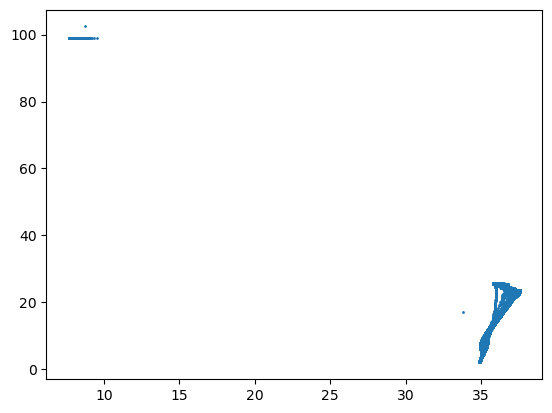

In [ ]:
s = ds.ctd_salinity.to_numpy()
t = ds.ctd_temperature.to_numpy()



plt.scatter(S, T, s = 1)

plt.show()

In [14]:
print(np.shape(t))

(167, 3023)
